<a href="https://colab.research.google.com/github/KsiuTretyakova/MachineLearning/blob/main/%D0%92%D1%81%D1%82%D1%83%D0%BF_%D0%B4%D0%BE_NLP_(%D0%9A%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%8F_%D0%B2%D1%96%D0%B4%D0%B3%D1%83%D0%BA%D1%96%D0%B2)_ML2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Вступ до NLP: Як комп’ютер розуміє текст? Класифікація відгуків

NLP — це галузь штучного інтелекту, яка вчить комп’ютер працювати з людською мовою.

Приклади NLP у повсякденному житті:

- Google Translate (переклад)
- Спам-фільтри в Gmail (класифікація)
- Siri / Alexa (розпізнавання команд)
- YouTube або TikTok коментарі (модерація)

Запитання та відповіді:

❓ Чи комп’ютер «розуміє» текст так, як людина?
🅰️ Ні. Він бачить текст як послідовність символів або слів, які треба перетворити у числа.


❓ Навіщо очищати текст перед аналізом?
🅰️ Щоб прибрати шум: зайві символи, слова, які не несуть інформації (як-от “the”, “and”).

#1. Підготовка середовища

In [ ]:
!pip install nltk

In [ ]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантажуємо ресурси NLTK
nltk.download('punkt')  # для токенізації
nltk.download('stopwords')  # список поширених слів (the, a, is...)
nltk.download('movie_reviews')  # корпус з відгуками


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

- punkt — модуль, який дозволяє розбивати текст на речення або слова.
- stopwords — список дуже поширених слів, які зазвичай не мають важливого значення.
- movie_reviews — набір відгуків (з NLTK): позитивні та негативні приклади.

#2. Завантаження даних

- movie_reviews.words(fileid) повертає список слів з файлу
- category — це "pos" або "neg" (позитивний/негативний відгук)
- documents — список з 2000 відгуків

In [ ]:
from nltk.corpus import movie_reviews
import random

# Створюємо список: (слова в відгуку, мітка - позитивний або негативний)
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Перемішуємо, щоб не було спочатку всі позитивні, а потім негативні
random.shuffle(documents)

In [ ]:
print(documents[10])

(['there', 'is', 'a', 'scene', 'early', 'in', 'soul', 'food', ',', 'george', 'tillman', "'", 's', 'comedy', '-', 'drama', 'about', 'a', 'large', 'african', '-', 'american', 'family', 'and', 'the', 'ordeals', 'they', 'go', 'through', 'during', 'a', 'crisis', ',', 'that', 'caught', 'me', 'completely', 'off', 'guard', '.', 'during', 'a', 'wedding', ',', 'the', 'groom', 'is', 'flirting', 'with', 'some', 'tramp', ',', 'and', 'in', 'an', 'attempt', 'to', 'to', 'prevent', 'a', 'scene', ',', 'his', 'mother', 'in', 'law', ',', 'played', 'by', 'irma', 'p', '.', 'hall', ',', 'comes', 'to', 'the', 'rescue', '.', 'the', 'way', 'in', 'which', 'she', 'does', 'this', 'makes', 'me', 'think', 'irma', 'p', '.', 'hall', 'is', 'one', 'of', 'the', 'greatest', 'actresses', 'around', 'right', 'now', '.', 'however', ',', 'this', 'is', 'just', 'one', 'magical', 'moment', 'in', 'a', 'movie', 'filled', 'with', 'them', '.', 'vanessa', 'williams', ',', 'vivica', 'fox', ',', 'and', 'nia', 'long', 'star', 'as', 'thre

#3. Попередня обробка тексту

- w.lower() — приводимо слово до нижнього регістру
- w.isalpha() — відкидаємо все, що не слово (цифри, символи)
- w.lower() not in stop_words — прибираємо "зайві" слова
- ps.stem() — скорочуємо слова до кореня (running → run)

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# d = {} -> dict() -> {'key1': 'value1', 'key2': 'value2'}
# s = set() -> {'val1', 'val2', 'val3'}
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

# Функція для очищення слів
def clear_words(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [ ]:
print(stop_words)

{'will', 'their', "you've", 'ain', "didn't", 'over', 'then', "doesn't", 'hadn', 'you', "mustn't", 'the', 've', 'had', 'in', 'few', 'to', 'just', "he'd", 'here', 'him', 'whom', 'where', 'd', 'mustn', 'own', 'i', "i'd", "it's", 'its', "they're", 'yourself', "shouldn't", 'y', 'through', 'which', 'couldn', 'when', 'haven', 'these', 'wouldn', 'down', 'very', "i've", 'any', 'below', 'no', 'don', 'o', 'themselves', 'why', "you're", "i'm", "you'll", 'yours', "shan't", 'than', 're', 'now', "won't", 'were', "she'd", 'again', 'same', 'until', "hasn't", 'we', 'mightn', "she's", "wasn't", 's', 'other', 'that', 'been', 'her', 'on', 'nor', 'this', 'weren', 'above', 'such', 'at', 'needn', "i'll", 'is', 'be', 'so', 'under', 'before', "that'll", "needn't", 'there', 't', 'himself', 'off', "they'll", 'did', 'myself', "aren't", 'shouldn', 'into', 'against', 'won', 'does', 'herself', 'because', 'ours', 'was', "couldn't", 'if', 'me', 'not', "we're", 'of', 'for', 'doing', 'those', "it'll", 'between', 'it', 'i

#4. Формування таблиці

In [ ]:
# Очищення всіх документів
cleaned_documents = [(" ".join(clear_words(doc)), label) for doc, label in documents]

In [ ]:
# a = [1, 2, 3]
# a, b, c = [1, 2, 3] -> a = 1, b = 2, c = 3

In [ ]:
print(cleaned_documents[10])

('scene earli soul food georg tillman comedi drama larg african american famili ordeal go crisi caught complet guard wed groom flirt tramp attempt prevent scene mother law play irma p hall come rescu way make think irma p hall one greatest actress around right howev one magic moment movi fill vanessa william vivica fox nia long star three sister gone way life william teri success lawyer frustrat husband mile attempt music career fox maxin strongest sister confirm stabil marriag wisdom son ahmad narrat film long bird hairdress last three get marri husband lem intens passion individu whose temper get best sometim never stop love center everyth irma p hall big mama jo everi sunday famili gather togeth dinner mama jo hous lot convers lot laugh occasion controversi mama jo presid famili like mother stern disciplin also care forgiv everyth go fine tragedi befal mama jo sudden chain reaction event begin destroy famili get bad sunday dinner even cancel without mama jo guidanc noon keep famili 

In [ ]:
# Створюємо таблицю
df = pd.DataFrame(cleaned_documents, columns=['review', 'label'])
df.head(11)

,review,label
0,anyon abl forse late night cabl show host gilb...,neg
1,synopsi blond crimin psychologist sarah choos ...,neg
2,cinemat speak gordon park origin great film bi...,pos
3,debat whether see ask one simpl question want ...,neg
4,mickey mous better watch back new critter town...,pos
5,movi pose question first five minut spend rest...,neg
6,last summer featur length version aveng hit th...,neg
7,mani peopl procrastin problem overcom high art...,pos
8,jessica lang one inconsist actress work today ...,neg
9,someth ben stiller make popular choic among ca...,pos


<Axes: title={'center': 'Розподіл відгуків'}, xlabel='label'>

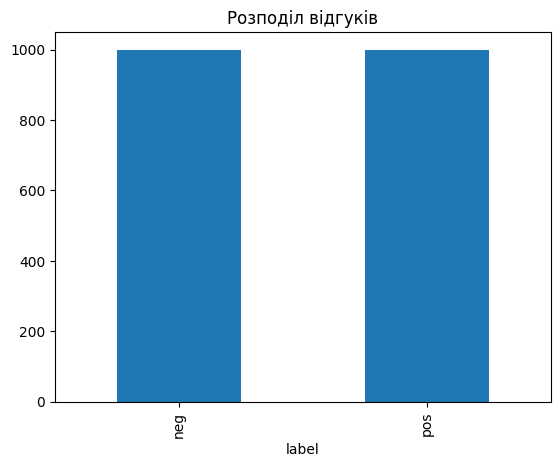

In [ ]:
# Подивимося кількість позитивних і негативних
df['label'].value_counts().plot(kind='bar', title='Розподіл відгуків')

#5. Перетворення тексту у числа

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])  # матриця "слів" → "числа"
y = df['label']

- `CountVectorizer` створює словник усіх слів і рахує, скільки разів кожне слово з’являється в тексті
- `X` — велика таблиця (рядки — відгуки, стовпці — слова, значення — кількість повторень)

In [ ]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 801)	1
  (0, 42)	2
  (0, 8108)	1
  (0, 12374)	1
  (0, 15083)	1
  (0, 2988)	1
  (0, 19950)	1
  (0, 10297)	2
  (0, 8749)	2
  (0, 9054)	1
  (0, 19953)	1
  (0, 24903)	1
  (0, 7714)	1
  (0, 333)	1
  (0, 2977)	9
  (0, 17646)	1
  (0, 23759)	2
  (0, 15129)	2
  (0, 14585)	4
  (0, 15547)	4
  (0, 3657)	1
  (0, 17841)	1
  (0, 11923)	1
  (0, 24910)	4
  (0, 13012)	1
  :	:
  (1999, 3762)	1
  (1999, 16219)	1
  (1999, 19926)	1
  (1999, 245)	1
  (1999, 13312)	1
  (1999, 16561)	1
  (1999, 16069)	1
  (1999, 20228)	1
  (1999, 522)	1
  (1999, 22262)	1
  (1999, 11010)	1
  (1999, 21546)	1
  (1999, 11640)	1
  (1999, 16293)	1
  (1999, 24459)	1
  (1999, 9953)	1
  (1999, 13394)	1
  (1999, 22058)	1
  (1999, 6155)	1
  (1999, 4260)	1
  (1999, 20772)	1
  (1999, 17863)	1
  (1999, 8931)	1
  (1999, 821)	1
  (1999, 7634)	1
0       neg
1       neg
2       pos
3       neg
4       pos
       ... 

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

# Ділимо дані на навчальні та тестові
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Створюємо модель наївного байєсівського класифікатора
model = MultinomialNB()

model.fit(X_train, y_train)

# Прогноз на тестових даних
y_pred = model.predict(X_test)

#6. Оцінка якості

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.785


- `accuracy_score` — частка правильних відповідей
- `confusion_matrix` — скільки відгуків правильно класифіковано як позитивні/негативні

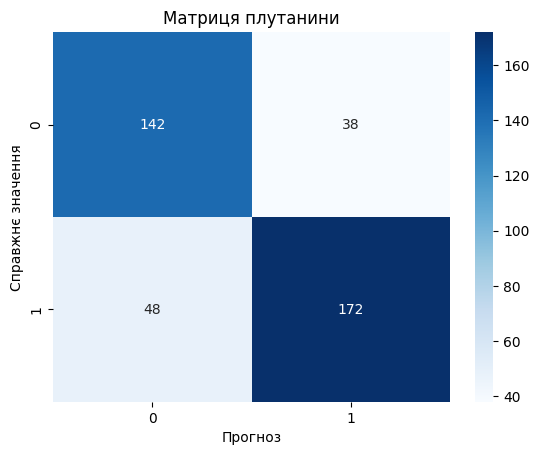

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Прогноз")
plt.ylabel("Справжнє значення")
plt.title("Матриця плутанини")
plt.show()

#7. Власна перевірка

Алгоритм перевірки:
1. Створюємо відгук
2. Очищаємо його
3. Перетворюємо в числа (через векторизатор)
4. Прогнозуємо результат

#8. Порівняння моделей: Naive Bayes vs Logistic Regression

- Точність обох моделей зазвичай 80–85%, але LogisticRegression часто трохи краща.
- У випадку простих текстових задач Naive Bayes — швидкий і ефективний, але логістична регресія краще працює на складніших даних.

## Multinomial Naive Bayes (MNB)

Naive Bayes — це сімейство моделей, що базуються на теоремі Байєса і працюють під припущенням, що всі ознаки незалежні одна від одної (наївне припущення).

Multinomial Naive Bayes — варіант, який найкраще підходить для тексту. Він працює з кількістю появ слів (а не просто фактом присутності).


📦 Як він працює:
- Вважає, що кожне слово в тексті має певну ймовірність з’явитись у позитивному або негативному тексті.
- Модель «вивчає» ці ймовірності з навчальних даних.
- Потім оцінює, до якого класу (позитив/негатив) з більшою ймовірністю належить новий текст.

✅ Коли використовувати:
- Коли дані — це тексти або відгуки.
- Коли важлива швидкість і простота.
- Якщо є багато текстових прикладів.

📊 Переваги:
- Дуже швидка та легка у використанні.
- Добре працює навіть з невеликою кількістю даних.
- Часто є «базовою» моделлю для тексту.

## Logistic Regression

Logistic Regression — це класична модель машинного навчання для бінарної класифікації (напр., "позитивний" чи "негативний").

Хоч назва «регресія», але модель виконує класифікацію, тобто вгадує клас.


📦 Як вона працює:
- Модель будує лінійну формулу на основі ознак (у нашому випадку — частотність слів).
- Потім використовує логістичну функцію (сигмоїду), щоб перетворити результат у ймовірність.
- Якщо ймовірність > 0.5 — класифікує як "позитивний", інакше — "негативний".

✅ Коли використовувати:
- Коли потрібно щось передбачити на основі даних.
- Коли хочеться трохи гнучкіша і точніша модель, ніж Naive Bayes.
- Коли важлива інтерпретація: Logistic Regression дозволяє побачити, які саме слова найбільше впливають на результат.

📊 Переваги:
- Часто точніша за Naive Bayes.
- Має багато налаштувань (регуляризація, кількість ітерацій).
- Працює з числовими, текстовими та іншими типами ознак.